In [1]:
import os
import load_dotenv
from load_dotenv import load_dotenv

# This function will load all the variable from the .env file and 
# make them available in the os.environ dictionary (env variables)
load_dotenv()

if os.environ.get("CLAUDE_API_KEY"):
    print("CLAUDE API KEY has been loaded")
else:
    raise ValueError("CLAUDE API KEY not found")

if os.environ.get("TAVILY_API_KEY"):
    print("TAVILY API KEY has been loaded")
else:
    raise ValueError("TAVILY API KEY not found")

CLAUDE API KEY has been loaded
TAVILY API KEY has been loaded


In [2]:
from langchain_anthropic import ChatAnthropic

llm_anthropic = ChatAnthropic(
    model = os.environ.get("CLAUDE_MODEL"),
    api_key = os.environ.get('CLAUDE_API_KEY'),
    temperature = 0,
    base_url = os.environ.get("CLAUDE_BASE_URL")
)
llm_anthropic

ChatAnthropic(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15', 'langchain-anthropic': '1.5.5'}}, model='vertex_ai.anthropic.claude-opus-4-6', max_tokens=4096, temperature=0.0, anthropic_api_url='https://genai-sharedservice-americas.pwcinternal.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

#### LLM with Pydantic Schema

In [3]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    topic: Literal['insta', 'twitter', 'linkedin'] = Field(..., description = "The topic for which to generate the post")

#### Parallel Schema

In [4]:
from typing import TypedDict, List

class graph_schema(TypedDict):

    topic: str
    insta: str
    twitter: str
    linkedin: str

In [5]:
def create_post_insta(state: graph_schema) -> graph_schema:

    # Extract the topic from the state
    topic = state["topic"]

    # Passing the topic to the LLM to generate an Instagram post
    post = llm_anthropic.invoke(f"Write an Instagram post about {topic}, Keep the tone casual and engaging.").content

    # Update the state with the generated post
    state['insta'] = post

    return {'insta' : post}

def create_post_twitter(state: graph_schema) -> graph_schema:

    # Extract the topic from the state
    topic = state["topic"]

    # Passing the topic to the LLM to generate a Twitter post
    post = llm_anthropic.invoke(f"Write a Twitter post about {topic}, Keep the tone quick.").content

    # Update the state with the generated post
    state['twitter'] = post

    return {'twitter' : post}


def create_post_linkedin(state: graph_schema) -> graph_schema:

    # Extract the topic from the state
    topic = state["topic"]

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm_anthropic.invoke(f"Write a LinkedIn post about {topic}, Keep the tone professional and informative.").content

    # Update the state with the generated post
    state['linkedin'] = post

    return {'linkedin' : post}

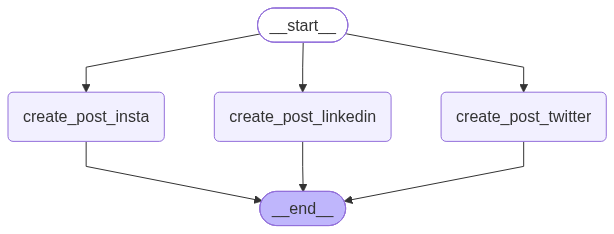

In [14]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(graph_schema)

# Adding nodes to the graph
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

# # Adding Edges to the graph
graph.add_edge(START, "create_post_insta")
graph.add_edge(START, "create_post_twitter")
graph.add_edge(START, "create_post_linkedin")

graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

parallel_graph = graph.compile()

Image(parallel_graph.get_graph().draw_mermaid_png())


In [ ]:
parallel_graph.invoke({
    "topic": "Artificial Intelligence",
    "insta": "",
    "twitter": "",
    "linkedin": ""
})